|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>The Naive Loop<h1>|
|<h2>Section:</h2>|<h1>The arithmetic<h1>|
|<h2>Lecture:</h2>|<h1><b>Is this waiting on bytes, or on arithmetic?<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# One question about a GPU

Does this machine wait for bytes? Or does it wait for arithmetic?

Every part of an inference engine answers that question. Ask it about one
forward pass of a 7B model. You can answer it on paper, before you write any
code.

In [2]:
params   = 7e9         # a 7B model
bytes_pp = 2           # bf16

weight_bytes = params * bytes_pp
print(f'weights: {weight_bytes/1e9:.0f} GB, and every one of them is read to make every token')

weights: 14 GB, and every one of them is read to make every token


### Step 1: read the weights

The GPU must pull all of those bytes out of memory to make one token.

In [3]:
# One mid-range card, to show the arithmetic. Every result below is a RATIO.
# So these two numbers do not reach the conclusion. ./vc info measures yours.
bandwidth = 380e9      # bytes/sec

read_seconds = weight_bytes / bandwidth
print(f'{weight_bytes/1e9:.0f} GB / {bandwidth/1e9:.0f} GB/s = {1000*read_seconds:.0f} ms just to read them')

14 GB / 380 GB/s = 37 ms just to read them


### Step 2: do the arithmetic

The GPU uses each weight once, in one multiply and one add. That is two
operations.

In [4]:
compute = 100e12       # FLOP/sec

def compute_seconds(batch):
  return (2 * params * batch) / compute

print(f'batch 1: {1000*compute_seconds(1):.2f} ms of arithmetic')
print(f'and     {1000*read_seconds:.0f} ms of reading')
print(f'\nthe arithmetic is {read_seconds/compute_seconds(1):.0f}x faster than fetching what it works on')

batch 1: 0.14 ms of arithmetic
and     37 ms of reading

the arithmetic is 263x faster than fetching what it works on


### Step 3: see what the batch changes

Read time does not depend on the batch. The GPU fetches the weights once. It
then uses them for every sequence in flight.

Compute time is proportional to the batch.

So one line is flat. The other line climbs.

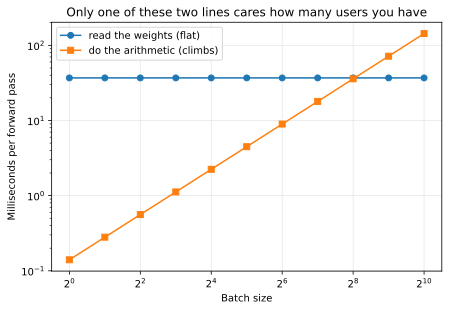

In [5]:
batches = np.array([1,2,4,8,16,32,64,128,256,512,1024])

read    = np.full_like(batches, read_seconds, dtype=float)
compute_t = np.array([compute_seconds(b) for b in batches])

plt.figure(figsize=(7,4.5))
plt.plot(batches, 1000*read,      'o-', label='read the weights (flat)')
plt.plot(batches, 1000*compute_t, 's-', label='do the arithmetic (climbs)')
plt.xscale('log', base=2); plt.yscale('log')
plt.xlabel('Batch size'); plt.ylabel('Milliseconds per forward pass')
plt.title('Only one of these two lines cares how many users you have')
plt.legend(); plt.grid(alpha=.3)
plt.show()

In [6]:
i  = np.argmax(compute_t > read)
lo, hi = batches[i-1], batches[i]
print(f'the lines cross between batch {lo} and batch {hi}')
print(f'below that, the GPU waits on memory. above it, it waits on math.')

the lines cross between batch 256 and batch 512
below that, the GPU waits on memory. above it, it waits on math.


### The same fact, without the units

Divide one time by the other. The seconds cancel. Two plain counts remain:

$$\text{hardware} = \frac{\text{FLOP/s}}{\text{bytes/s}} \qquad
  \text{workload} = \frac{2NB}{2N} = B$$

The workload ratio is the batch size. The 2 and the N cancel. So one question
remains. Is your batch larger than this number?

In [7]:
ridge = compute / bandwidth
print(f'this hardware: {ridge:.0f} FLOP per byte')
print(f'batch < {ridge:.0f}  ->  memory-bound, the arithmetic units idle')
print(f'batch > {ridge:.0f}  ->  compute-bound, the memory system idles')

this hardware: 263 FLOP per byte
batch < 263  ->  memory-bound, the arithmetic units idle
batch > 263  ->  compute-bound, the memory system idles


### Now change the machine

Nothing above describes one particular GPU. `read_seconds` and
`compute_seconds` carry the same units. Their ratio is therefore a pure
number, and that pure number is the only value you need.

The table below holds three real cards. Watch the ridge.

        card    GB/s   TFLOP/s   ridge  (FLOP per byte)
    RTX 4090    1008       165     164
   A100 80GB    2039       312     153
    H100 SXM    3350       989     295


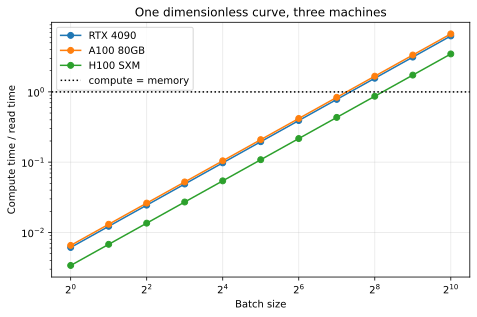

In [8]:
CARDS = {
  #               bandwidth B/s,  bf16 FLOP/s
  'RTX 4090':     (1008e9,        165e12),
  'A100 80GB':    (2039e9,        312e12),
  'H100 SXM':     (3350e9,        989e12),
}

print(f"{'card':>12} {'GB/s':>7} {'TFLOP/s':>9} {'ridge':>7}  (FLOP per byte)")
for name, (bw, fl) in CARDS.items():
  print(f'{name:>12} {bw/1e9:>7.0f} {fl/1e12:>9.0f} {fl/bw:>7.0f}')

plt.figure(figsize=(7.5,4.6))
for name, (bw, fl) in CARDS.items():
  read = weight_bytes/bw
  comp = 2*params*batches/fl
  plt.plot(batches, comp/read, 'o-', label=name)
plt.axhline(1.0, color='k', ls=':', label='compute = memory')
plt.xscale('log', base=2); plt.yscale('log')
plt.xlabel('Batch size'); plt.ylabel('Compute time / read time')
plt.title('One dimensionless curve, three machines')
plt.legend(); plt.grid(alpha=.3); plt.show()

### What to remember from this notebook

Remember no millisecond and no batch size. Remember this:

> The **ridge** is FLOP/s divided by bytes/s. It is a plain count with no
> units left in it. Your workload sits at **B** on the same axis.
>
> Below the ridge the arithmetic units wait. Above the ridge the memory system
> waits.

Two results follow. Both are worth more than any single measurement.

**The ridge belongs to the chip. You cannot move it.** Every technique in this
course moves *B* instead. Or it makes the bytes smaller, so that the same *B*
sits further to the right.

**Better hardware makes the problem worse.** Look at the table. The H100 has
three times the bandwidth of the 4090, and its ridge is higher. Its tensor
cores grew faster than its memory. So a modern card needs a larger batch to
stay busy. The KV cache still stops you from reaching that batch.

This is why the course teaches software. The next notebook describes the
obstacle.

    ./vc info